# Macro-ECL exploratory notebook

Tape, macros, features vs default, scenarios, and holdout-style tables.
Run from the **project root** kernel (`Python (macro-ecl)`).

```bash
cd ~/Downloads/macro-ecl
source venv/bin/activate
python3 -m ipykernel install --user --name macro-ecl --display-name "Python (macro-ecl)"
```

This notebook does **not** retrain models. For a full run use `PYTHONPATH=. python3 scripts/run_all.py`.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "config" / "config.yaml").exists():
    ROOT = ROOT.parent
print("ROOT", ROOT)

with open(ROOT / "config" / "config.yaml") as f:
    CFG = yaml.safe_load(f)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT /Users/udayveersinghandotra/macro-ecl
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## 1. Raw files

In [7]:
loans_p = ROOT / CFG["paths"]["raw_loan_data"]
macro_p = ROOT / CFG["paths"]["raw_macro_data"]
tape_p = ROOT / CFG["paths"]["processed_tape"]
scen_p = ROOT / CFG["paths"]["macro_forecasts"]

for p in (loans_p, macro_p, tape_p, scen_p):
    print(f"{'OK' if p.exists() else 'MISSING':8} {p}  {p.stat().st_size if p.exists() else 0:,} bytes")

OK       /Users/udayveersinghandotra/macro-ecl/data/raw/sba_raw.csv  179,430,516 bytes
OK       /Users/udayveersinghandotra/macro-ecl/data/raw/historical_macro_data.csv  2,641 bytes
OK       /Users/udayveersinghandotra/macro-ecl/data/processed/sba_portfolio_tape.csv  193,428,244 bytes
OK       /Users/udayveersinghandotra/macro-ecl/data/scenarios/macro_forecasts.csv  330 bytes


## 2. Raw loan tape (head + layout)

In [8]:
raw = pd.read_csv(loans_p, nrows=5, low_memory=False)
print("columns", list(raw.columns))
raw.head()

columns ['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState', 'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'ChgOffDate', 'DisbursementDate', 'DisbursementGross', 'BalanceGross', 'MIS_Status', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,84,4,2,0,0,1,0,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,60,2,2,0,0,1,0,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,180,7,1,0,0,1,0,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,60,2,1,0,0,1,0,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,240,14,1,7,7,1,0,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [9]:
kaggle_cols = {"GrAppv", "SBA_Appv", "MIS_Status", "ChgOffPrinGr", "NoEmp", "Term"}
print("kaggle_sba_national layout:", kaggle_cols.issubset(set(raw.columns)))

kaggle_sba_national layout: True


## 3. FRED macros

          date    real_gdp  unemployment_rate
100 2025-01-01 23,548.2100             4.0000
101 2025-04-01 23,770.9760             4.2000
102 2025-07-01 24,026.8340             4.3000
103 2026-01-01 24,180.4190             4.3000
104 2026-04-01 24,269.6130             4.3000
rows 105 2000-01-01 00:00:00 → 2026-04-01 00:00:00


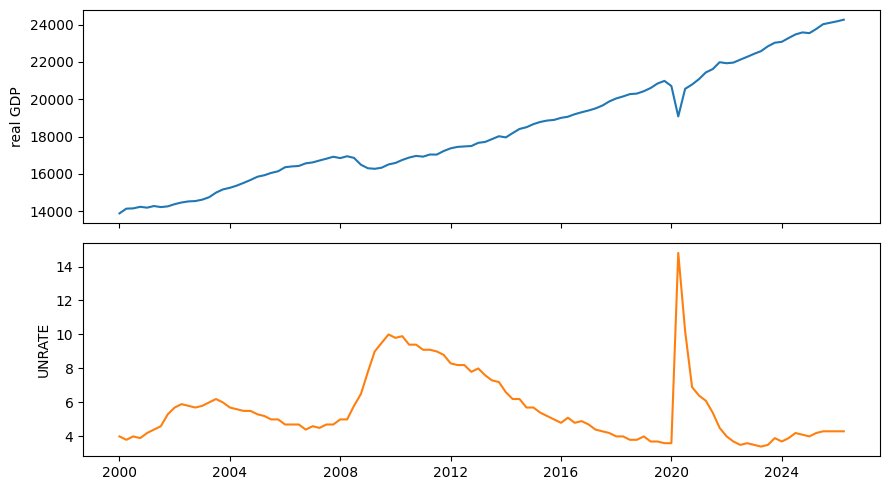

In [10]:
macro = pd.read_csv(macro_p)
macro["date"] = pd.to_datetime(macro.iloc[:, 0] if "date" not in macro.columns else macro["date"], errors="coerce")
macro = macro.sort_values("date")
print(macro.tail())
print("rows", len(macro), macro["date"].min(), "→", macro["date"].max())

fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
if "real_gdp" in macro.columns:
    ax[0].plot(macro["date"], macro["real_gdp"])
    ax[0].set_ylabel("real GDP")
u = "unemployment_rate" if "unemployment_rate" in macro.columns else "unemp"
if u in macro.columns:
    ax[1].plot(macro["date"], macro[u], color="C1")
    ax[1].set_ylabel("UNRATE")
fig.tight_layout()
plt.show()

## 4. Processed portfolio tape

Built by `src/data_prep/sba_credit_pipeline.py`. If missing, run `PYTHONPATH=. python3 scripts/run_all.py` first.

In [11]:
tape = pd.read_csv(tape_p, low_memory=False)
print("rows", len(tape), "cols", tape.shape[1])
print(tape.dtypes)
tape.head()

rows 897167 cols 32
source                     object
loan_id                     int64
exposure_at_default       float64
gr_appv                   float64
sba_appv                  float64
sba_guaranteed_portion    float64
sba_unguaranteed_share    float64
maturity_years            float64
real_estate_backed          int64
collateral_value          float64
ltv                       float64
leverage                  float64
no_emp                      int64
liquidity_ratio           float64
default_flag                int64
loanstatus                 object
loss_severity             float64
origination_date           object
asof_date                  object
chgoff_date                object
years_to_default          float64
days_past_due               int64
origination_pd            float64
new_business                int64
lowdoc                      int64
revolving                   int64
urban_rural                 int64
state                      object
naics2                      

,source,loan_id,exposure_at_default,gr_appv,sba_appv,sba_guaranteed_portion,sba_unguaranteed_share,maturity_years,real_estate_backed,collateral_value,ltv,leverage,no_emp,liquidity_ratio,default_flag,loanstatus,loss_severity,origination_date,asof_date,chgoff_date,years_to_default,days_past_due,origination_pd,new_business,lowdoc,revolving,urban_rural,state,naics2,macro_date,realgdp_growth_lag_1Q,unemp_lag_1Q
0,kaggle_sba_national,7756080004,"52,500.0000","52,500.0000","47,250.0000",0.9000,0.1000,26.5000,1,"52,500.0000",1.0000,0.1000,3,0.3466,1,CHGOFF,0.1891,1970-02-26,1970-02-26,1991-03-22,21.0650,0,NaN,0,0,0,0,CO,0,NaN,0.0061,5.2000
1,kaggle_sba_national,7891160007,"100,000.0000","100,000.0000","90,000.0000",0.9000,0.1000,13.5000,0,"50,000.0000",2.0000,0.1000,20,0.7611,1,CHGOFF,0.0339,1970-02-27,1970-02-27,1993-09-29,23.5866,0,NaN,0,0,0,0,NY,0,NaN,0.0061,5.2000
2,kaggle_sba_national,8064180003,"74,952.0000","85,000.0000","76,500.0000",0.9000,0.1000,5.0000,0,"37,476.0000",2.0000,0.1000,11,0.6212,1,CHGOFF,0.7747,1970-04-14,1970-04-14,1991-12-27,21.7029,0,NaN,0,0,0,0,IL,0,NaN,0.0061,5.2000
3,kaggle_sba_national,7801190002,"15,000.0000","15,000.0000","10,000.0000",0.6667,0.3333,30.0000,1,"15,000.0000",1.0000,0.3333,4,0.4024,1,CHGOFF,0.0737,1970-05-08,1970-05-08,2005-09-23,30.0000,0,NaN,0,0,0,0,MO,0,NaN,0.0061,5.2000
4,kaggle_sba_national,8137670010,"80,000.0000","80,000.0000","72,000.0000",0.9000,0.1000,16.0000,0,"40,000.0000",2.0000,0.1000,1,0.1733,1,CHGOFF,0.2735,1970-06-03,1970-06-03,1990-08-30,20.2409,0,NaN,0,0,0,0,UT,0,NaN,0.0061,5.2000


In [12]:
if "asof_date" in tape.columns:
    tape["asof_date"] = pd.to_datetime(tape["asof_date"], errors="coerce")
print("default_rate", float(tape["default_flag"].mean()) if "default_flag" in tape.columns else None)
print("ead_sum", float(tape["exposure_at_default"].sum()) if "exposure_at_default" in tape.columns else None)
print("asof", tape["asof_date"].min() if "asof_date" in tape.columns else None,
      "→", tape["asof_date"].max() if "asof_date" in tape.columns else None)
if "source" in tape.columns:
    print(tape["source"].value_counts(dropna=False).head())

default_rate 0.1810610510640717
ead_sum 180867103981.0
asof 1970-02-26 00:00:00 → 2014-12-31 00:00:00
source
kaggle_sba_national    897167
Name: count, dtype: int64


## 5. Outcome mix and size

,n,ead_sum,ead_p50
default_flag,,,
0,734725,"159,725,687,280.0000","100,487.0000"
1,162442,"21,141,416,701.0000","60,000.0000"


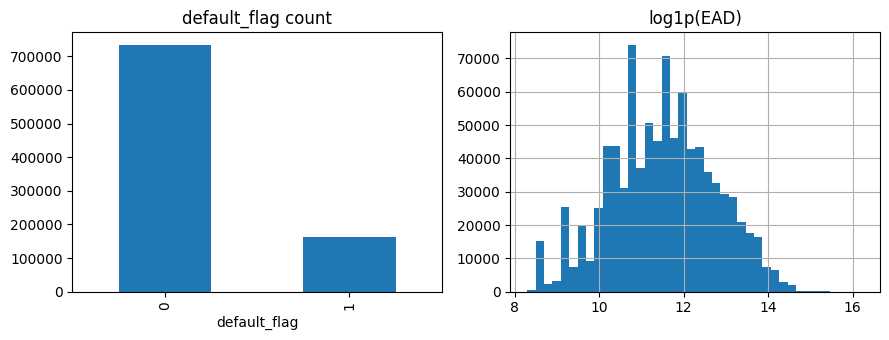

In [13]:
if {"default_flag", "exposure_at_default"}.issubset(tape.columns):
    g = tape.groupby("default_flag").agg(
        n=("default_flag", "size"),
        ead_sum=("exposure_at_default", "sum"),
        ead_p50=("exposure_at_default", "median"),
    )
    display(g)
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
    tape["default_flag"].value_counts().sort_index().plot.bar(ax=ax[0], title="default_flag count")
    np.log1p(tape["exposure_at_default"].clip(lower=0)).hist(bins=40, ax=ax[1])
    ax[1].set_title("log1p(EAD)")
    fig.tight_layout()
    plt.show()

## 6. Feature means by default (why macros barely rank)

On this tape charged-off names do **not** sit at higher unemployment. Ranking comes from leverage (unguaranteed share) and the headcount proxy.

,leverage,liquidity_ratio,realgdp_growth_lag_1Q,unemp_lag_1Q,maturity_years,days_past_due
default_flag,,,,,,
0,0.2759,0.4742,0.0062,5.4069,10.2331,0.0000
1,0.3555,0.3949,0.0060,5.1910,4.7359,0.0000


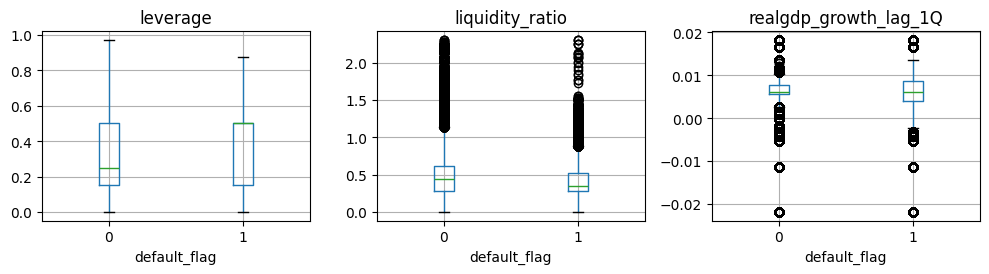

In [14]:
feats = [c for c in [
    "leverage", "liquidity_ratio", "guarantee_share",
    "realgdp_growth_lag_1Q", "unemp_lag_1Q",
    "maturity_years", "days_past_due",
] if c in tape.columns]
display(tape.groupby("default_flag")[feats].mean())

fig, axes = plt.subplots(1, min(3, len(feats)), figsize=(10, 3))
if not hasattr(axes, "__len__"):
    axes = [axes]
for ax, c in zip(axes, feats[:3]):
    tape.boxplot(column=c, by="default_flag", ax=ax)
    ax.set_title(c)
    ax.set_xlabel("default_flag")
plt.suptitle("")
fig.tight_layout()
plt.show()

## 7. Origination years vs FRED start (2000)

pre-2000 share 0.3639378175969468


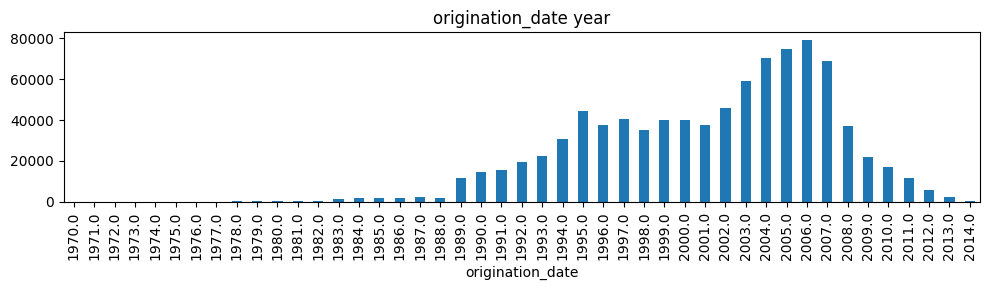

In [15]:
dcol = "origination_date" if "origination_date" in tape.columns else "asof_date"
if dcol in tape.columns:
    d = pd.to_datetime(tape[dcol], errors="coerce")
    print("pre-2000 share", float((d < "2000-01-01").mean()))
    d.dt.year.value_counts().sort_index().plot(kind="bar", figsize=(10, 3), title=f"{dcol} year")
    plt.tight_layout()
    plt.show()

## 8. Scenario file

In [16]:
if scen_p.exists():
    scen = pd.read_csv(scen_p)
    display(scen)
else:
    print("No scenarios yet — run scripts/run_all.py")

,scenario_name,realgdp_growth,unemp,realgdp_growth_lag_1Q,unemp_lag_1Q
0,baseline,0.0024,4.6887,0.0024,4.6887
1,adverse,-0.0176,6.1887,-0.0176,6.1887
2,severe,-0.0476,7.6887,-0.0476,7.6887


## 9. Last engine run (if present)

In [17]:
import json
last = ROOT / "reports" / "last_run.json"
if last.exists():
    js = json.loads(last.read_text())
    print("PWECL", js.get("pwecl"))
    print("portfolio", js.get("portfolio"))
    mets = (js.get("metrics") or {}).get("model")
    print("holdout HGB", mets)
else:
    print("reports/last_run.json not found")

PWECL 6823895968.047734
portfolio {'total_facilities': 897167, 'total_ead': 180867103981.0, 'source': 'kaggle_sba_national', 'layout': 'kaggle_sba_national', 'default_rate': 0.1810610510640717}
holdout HGB {'n': 269151, 'default_rate': 0.18106193177807253, 'mean_pred': 0.18109944324093125, 'brier': 0.1391972140355381, 'auc': 0.6823915641422879, 'calibration_slope': 0.9876715101995293}


## 10. Optional: score stored PD model on a sample

In [ ]:
import joblib

pd_path = ROOT / CFG["paths"]["pd_model"]
if pd_path.exists():
    blob = joblib.load(pd_path)
    model = blob["horizon_1y"] if isinstance(blob, dict) else blob
    feats = CFG["model_features"]["pd_financials"] + CFG["model_features"]["macro_lags"]
    feats = [c for c in feats if c in tape.columns]
    sample = tape[feats].head(5000).fillna(0)
    p = model.predict_proba(sample)[:, 1]
    print("sample mean PD", float(p.mean()), "min/max", float(p.min()), float(p.max()))
    plt.hist(p, bins=30)
    plt.title("HGB PD on first 5k rows")
    plt.show()
else:
    print("no pd_model.pkl — train first")